# LSTM Autoencoder-based Anomaly Detection

___
## Introduction
This project is a personal practice attempt at performing anomaly detection on a multivariate time-series dataset. The dataset chosen is the Tennessee Eastman dataset, and anomalies in the data are detected through the reconstruction errors of an LSTM autoencoder.

In this approach, the autoencoder is first trained to reproduce the data of a 'normal' dataset. The assumption is that when anomalous data is later presented to the autoencoder, it would struggle to reproduce them and therefore higher reproduction/reconstruction errors would be incurred.
___
## The Tennessee Eastman Dataset
Source: https://www.kaggle.com/datasets/averkij/tennessee-eastman-process-simulation-dataset
- Download the dataset, and make sure the following four files are in the `./data/` directory
    - `TEP_FaultFree_Testing.RData`
    - `TEP_FaultFree_Training.RData`
    - `TEP_Faulty_Testing.RData`
    - `TEP_Faulty_Training.RData`

- More insight about the Tennessee Eastman Dataset can be found here:
    - https://keepfloyding.github.io/posts/Ten-East-Proc-Intro/
    - https://keepfloyding.github.io/posts/data-explor-TEP-1/
    - https://keepfloyding.github.io/posts/data-explor-TEP-2/
    - https://keepfloyding.github.io/posts/data-explor-TEP-3/


___
## Overview of Code
The essential code are found in the `src` directory.
- `datapipeline.py`: Functions for loading the Tennessee Eastman dataset and preparing the data for the autoencoder. Key parameters are loaded from `./configs/config.yaml`.
- `autoencoder.py`: Definitions of the encoder, decoder and autoencoder classes
- `ae_utils.py`: Functions for building, training, saving, loading, and inferencing from the autoencoder.
- `eval_tools.py`: Definition of an evaluator class specially designed for the autoencoder's anomaly detection performance on the Tennessee Eastman dataset.

Example of how the code can be used for anomaly detection is shown in the following section.

If adapting the LSTM autoencoder for other datasets or for other purpose, `autoencoder.py` and `ae_utils.py` can probably be reused with minimal modification. 

___
## Anomaly Detection Process
This process detects anomalies based on the reconstruction errors of the autoencoder (AE). Since the dataset is a time-series dataset, the AE will be a LSTM AE.

We will be training the AE with just the fault-free training dataset to establish what normal data should look like.

The AE will then be tested through the reconstruction of data from both the fault-free and faulty testing datasets.

### 1. Load Training Data

In [1]:
from src.datapipeline import load_train_data
from src.general_utils import load_config

config = load_config('./configs/config.yaml')
X_train_df, X_val_df, dl_train, dl_val, scaler = load_train_data(config)

INFO - Configuration loaded from ./configs/config.yaml


Loading train data, this may take a while...


INFO - Training RData loaded.
INFO - Training/validation dataframes and dataloaders returned.
INFO - Training and validation dataframes sizes are (225000, 55) & (25000, 55).


### 2. Set Up AE 

In [2]:
from src.ae_utils import AEUtils

# each window shape is (batch_size, seq_len, num_features)
input_size = next(iter(dl_train))[0].shape[2]

ae_model = AEUtils(input_size=input_size,
                   embed_size=config['ae_params']['embed_size'],
                   num_layers=config['ae_params']['num_layers'],
                   dropout=config['ae_params']['dropout'],
                   lr=config["train_params"]['lr'])

INFO - Autoencoder and optimiser set up.


### 3. Train AE

Training model for 3000 epochs: 100%|██████████| 3000/3000 [39:16<00:00,  1.27epoch/s, Train Loss=0.6818, Validation Loss=0.6972]
INFO - Autoencoder training epochs 0 to 3000 completed in 2357s.


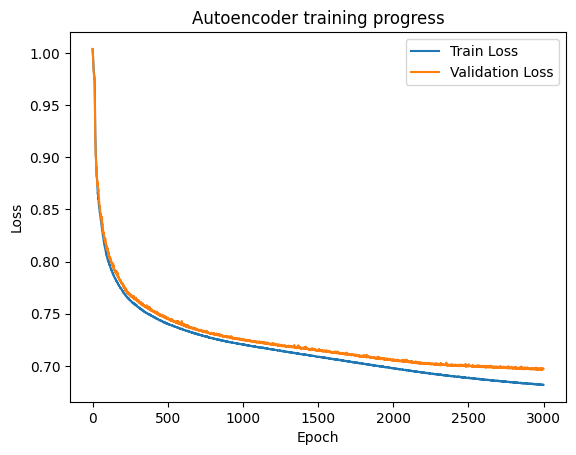

In [3]:
ae_model.train(dl_train=dl_train, dl_val=dl_val, num_epochs=config['train_params']['num_epochs'], plot_loss=True)

In [6]:
from src.ae_utils import save_ae

save_path = config['save_path']

save_ae(ae_model, scaler, save_path)

INFO - Autoencoder saved in ./models/ae_model_saved.pth.


### 3.1. Load AE & Resume Training

The `save_ae`, `load_ae` and `train_ae` functions allow for training to be resumed from the saved data.

INFO - Autoencoder and optimiser set up.
INFO - Autoencoder loaded from ./models/ae_model_saved.pth.
Training model for 1000 epochs: 100%|██████████| 1000/1000 [12:58<00:00,  1.29epoch/s, Train Loss=0.6724, Validation Loss=0.6957]
INFO - Autoencoder training epochs 0 to 1000 completed in 778s.


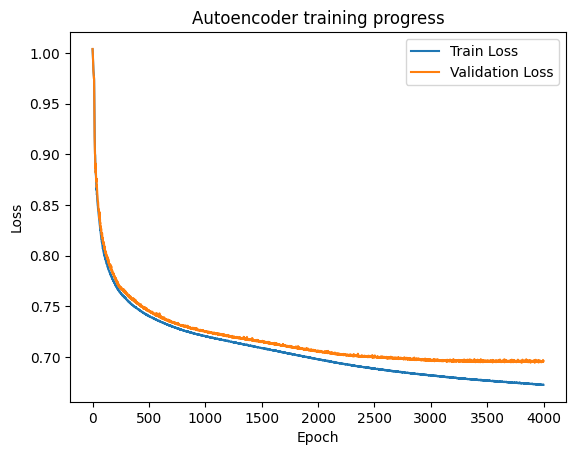

In [8]:
from src.ae_utils import load_ae

ae_model, scaler = load_ae(save_path)

# resume training for an additional 1000 epochs
num_epochs = ae_model.curr_epoch + 1000

ae_model.train(dl_train=dl_train, dl_val=dl_val, num_epochs=num_epochs, plot_loss=True)

In [9]:
save_ae(ae_model, scaler, save_path)

INFO - Autoencoder saved in ./models/ae_model_saved.pth.


### 4. Data Reconstruction and Anomaly Detection with AE
The Tennessee Eastman test dataset has fault-free as well as faulty data to test with.

### 4.1 Load Test Data
There's the fault-free data, and faults no. 1-20. Each set has 500 simulation runs. We will only load 20 runs of each for testing.

In [10]:
from src.datapipeline import load_inference_data

# modify config.yaml to change number of runs loaded
X_test_df, dl_test = load_inference_data(config, scaler)

Loading test data, this may take a while...


INFO - Faultfree test RData loaded.
INFO - Faulty test RData loaded.
INFO - Test dataframe and dataloader returned, 20 runs for each faultNumber.
INFO - Test dataframe size is (403200, 55).


### 4.2 Process Test Data for Evaluation
Creating the `AE_eval` class object will trigger an inference run on the given test data.

In [12]:
from src.eval_tools import AE_eval

ae_eval = AE_eval(X_test_df, dl_test, ae_model, scaler)

Autoencoder inferencing for 53 batches: 100%|██████████| 53/53 [00:02<00:00, 24.76batch/s]
INFO - Autoencoder inferencing for 53 test batches completed.


Calling the `reconstruction_RMSE()` method populates a dataframe with the RMSE of all test simulation runs.

In [13]:
ae_eval.reconstruction_RMSE()

faultNumber: 100%|██████████| 21/21 [00:58<00:00,  2.78s/it]


,faultNumber,simulationRun,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,0.880089,1.003087,0.925694,0.907644,1.017489,1.016953,0.426612,0.959295,...,0.898315,0.877591,1.006192,0.590311,0.881636,1.024897,1.000829,0.264655,0.971868,1.041640
1,0.0,2.0,0.791371,0.999688,0.850293,0.854301,0.996791,1.012993,0.373188,0.916612,...,0.835365,0.788064,0.957395,0.502607,0.877210,1.030475,0.962912,0.190672,0.983016,1.008679
2,0.0,3.0,0.792839,1.085337,0.868967,0.867859,0.970959,0.983802,0.459200,0.928987,...,0.884623,0.795389,1.032016,0.571718,0.879546,0.977487,1.000270,0.297306,0.989136,1.026241
3,0.0,4.0,0.826583,1.065298,0.880445,0.865911,1.009061,1.021981,0.439997,0.905820,...,0.885976,0.828836,0.968427,0.507255,0.832542,0.998083,0.961719,0.287971,0.981225,0.969403
4,0.0,5.0,0.821180,0.986490,0.882254,0.908796,0.987980,1.001493,0.379872,0.928540,...,0.876636,0.820239,0.946197,0.503354,0.893168,1.022826,1.002401,0.218615,0.954146,0.977718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,20.0,16.0,0.913361,1.052760,0.957471,0.954048,0.993662,1.041146,0.931407,0.995391,...,0.972520,0.909973,0.984693,4.769154,1.012694,1.000100,1.023412,0.569944,1.064683,1.002294
416,20.0,17.0,0.900638,1.098103,0.964945,0.916011,1.031741,1.004140,0.873783,0.983868,...,0.926652,0.897734,0.976432,4.786109,0.951849,0.977040,1.027259,0.476004,1.056296,1.026162
417,20.0,18.0,0.911694,1.114207,0.941790,0.949755,1.013030,1.049410,0.983578,0.977883,...,0.958664,0.911338,0.983964,4.657758,0.972685,0.990367,1.017721,0.529892,1.094599,1.022070
418,20.0,19.0,0.911375,1.090411,0.927493,0.928917,1.002062,1.074637,0.890171,0.958829,...,0.938975,0.913829,0.984918,4.752060,0.948111,1.012444,1.044894,0.607917,1.127797,1.013158


Verify that the fault-free test set has low RMSE for all features. 

The RMSE is calculated on standardised feature values. So we would expect the RMSE to be around 1 or lower.

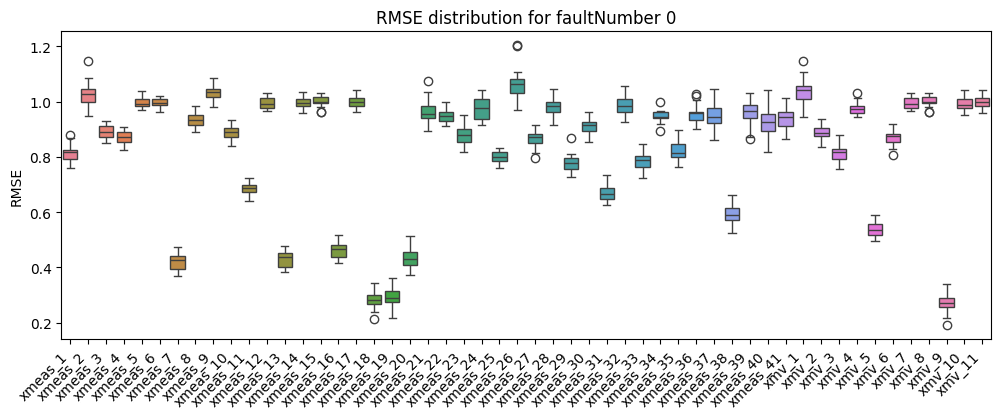

In [14]:
ae_eval.plot_RMSE_distributions(faultNumber=0)

Verify that the reconstructed data follows the general pattern of the test data.

The semi-transparent area show the min-max of the 20 runs.

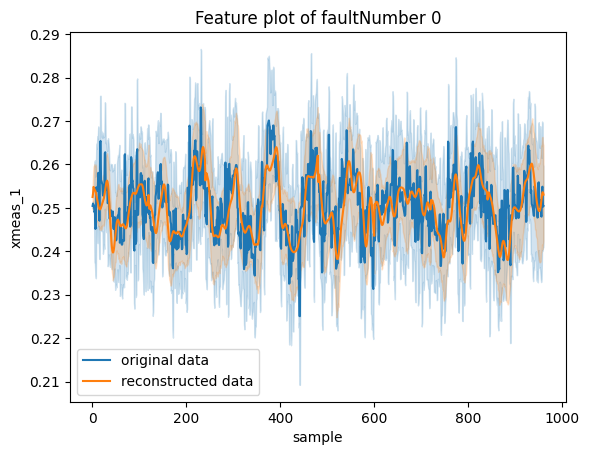

In [15]:
ae_eval.plot_feature(feature='xmeas_1', faultNumber=0)

For each `faultNumber`, which features have RMSE that exceed a certain threshold value?

In [16]:
ae_eval.find_high_RMSE(RMSE_threshold=1.4)

,faultNumber,highMSEcolumns
0,0,[]
1,1,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ..."
2,2,"[xmeas_3, xmeas_4, xmeas_6, xmeas_7, xmeas_10,..."
3,3,[]
4,4,[xmv_10]
5,5,"[xmeas_20, xmv_11]"
6,6,"[xmeas_1, xmeas_2, xmeas_3, xmeas_4, xmeas_7, ..."
7,7,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ..."
8,8,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ..."
9,9,[]


Visually inspect an example to see what the RMSE across features look like.

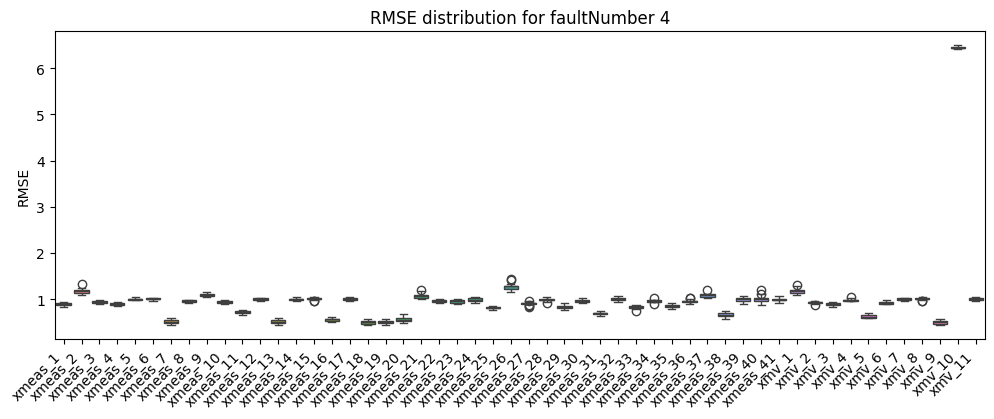

In [17]:
ae_eval.plot_RMSE_distributions(faultNumber=4)

Visually inspect the time-series to see how the data is anomalous. Compare that with the fault-free case.

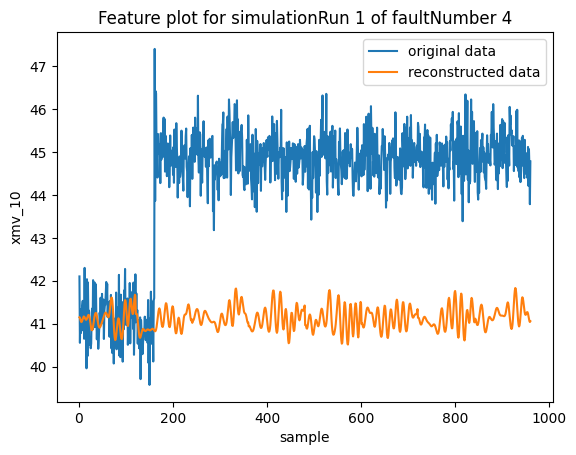

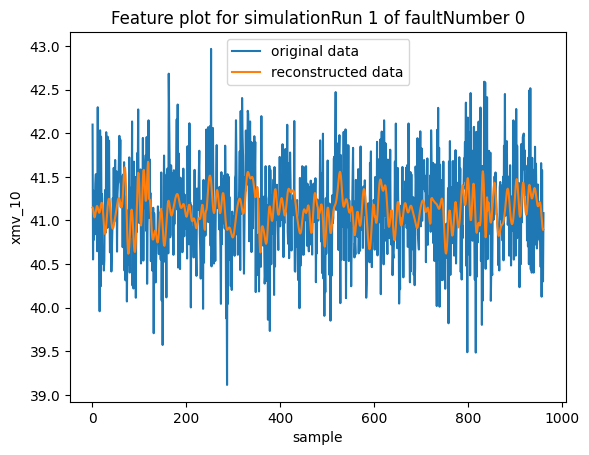

In [18]:
feature = 'xmv_10'

ae_eval.plot_feature(feature=feature, faultNumber=4, simulationRun=1)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=1)

___
## Limitations
It can be seen that certain faulty datasets (e.g. `faultNumber=3`) did not have any features that were flagged as having a high RMSE, and thus would not be detected as anomalous. A closer inspection of the original and reconstructed data would be necessary to understand where the approach fails. 

Without further analysis, one possible failure mode that we can easily imagine is if the faulty data is characterised by an *absence* of noise or variations. The reconstruction RMSE would more likely be lower rather than higher than in the fault-free case, and escape detection in this approach.

From the feature plots, we can tell that the autoencoder is unable to reproduce all the noise and random high frequency variations even in the fault-free data, and behaves somewhat like a low-pass filter. This is not unexpected as the embeddings would only retain the salient features in the data, and this should not include random fluctuations. But this also prevents us from detecting anomalies that produce lower reproduction RMSE values via this approach.

